# What is the most optimal skill to learn for Data Analysts?
### Methodology
- Group skills to determine median salary and likelihood of being in posting
- Visualize median salary VS percent skill demand
- (Optimal) Determine if certain technologies are more prevalent

In [1]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Loading the dataset
df = pd.read_csv('../data_jobs.csv')


# Data Cleaning
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
df_india = df[(df['job_title_short'] == 'Data Engineer') & (df['job_country'] == 'India')].dropna(subset='salary_year_avg').copy()

In [3]:
df_india_explode = df_india.explode('job_skills')
df_india_explode[['salary_year_avg','job_skills']].head(5)

,salary_year_avg,job_skills
2022,156500.0,java
2022,156500.0,t-sql
2022,156500.0,sql
2022,156500.0,azure
2022,156500.0,power bi


In [4]:
df_DE_skills =df_india_explode.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(by='count', ascending=False)
df_DE_skills = df_DE_skills.rename(columns={'count':'skill_count', 'median':'median_salary'})
DE_job_count = len(df_india)
df_DE_skills['skill_percent'] = df_DE_skills['skill_count'] / DE_job_count * 100

df_DE_skills = df_DE_skills.head(10)

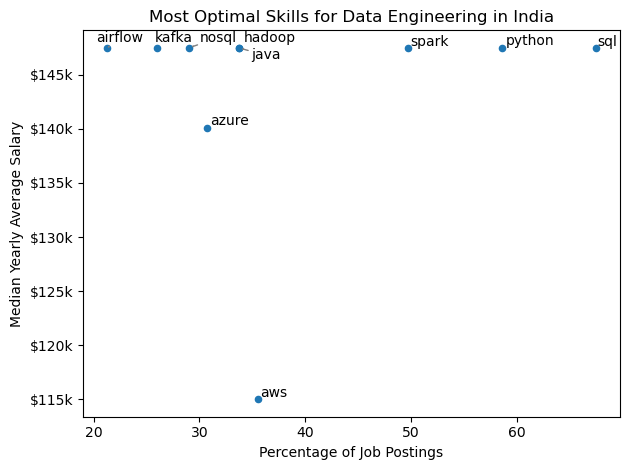

In [5]:
from adjustText import adjust_text

df_DE_skills.plot(kind='scatter', x='skill_percent', y='median_salary')
texts=[]

for i, txt in enumerate(
    df_DE_skills.index):
    texts.append(plt.text(
        df_DE_skills['skill_percent'].iloc[i], 
    df_DE_skills['median_salary'].iloc[i], txt))
adjust_text(texts, arrowprops=dict(arrowstyle="->", color='gray',lw=1.0))

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}k'))

plt.xlabel('Percentage of Job Postings')
plt.ylabel('Median Yearly Average Salary')
plt.title('Most Optimal Skills for Data Engineering in India')
plt.tight_layout()
plt.show()

#### Coloring by Technology

In [6]:
df_technology = df['job_type_skills'].copy()

# removes duplicates
df_technology = df_technology.drop_duplicates()

# removes NaN values
df_technology = df_technology.dropna()

# combines all dictionaries into one
technology_dict = {}
for row in df_technology:
    row_dict = ast.literal_eval(row)  # convert string to dictionary
    for key, value in row_dict.items():
        if key in technology_dict:  # if key already exists in technology_dict, add value to existing value
            technology_dict[key] += value
        else:                       # if key does not exist in technology_dict, add key and value
            technology_dict[key] = value

# removing duplicates by converting values to set then back to list
for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))

In [7]:
# turning dictionary into dataframe
df_technology = pd.DataFrame(list(technology_dict.items()), columns=['technology', 'skills'])

df_technology = df_technology.explode('skills')

df_technology

,technology,skills
0,analyst_tools,msaccess
0,analyst_tools,splunk
0,analyst_tools,sap
0,analyst_tools,alteryx
0,analyst_tools,powerpoint
...,...,...
9,sync,google chat
9,sync,wire
9,sync,zoom
9,sync,mattermost


In [8]:
# merging df_DE_skills and df_technology
df_plot = df_DE_skills.merge(df_technology, left_on='job_skills', right_on='skills')
df_plot

,skill_count,median_salary,skill_percent,technology,skills
0,114,147500.0,67.455621,programming,sql
1,99,147500.0,58.579882,programming,python
2,84,147500.0,49.704142,libraries,spark
3,60,115000.0,35.502959,cloud,aws
4,57,147500.0,33.727811,programming,java
5,57,147500.0,33.727811,libraries,hadoop
6,52,140120.5,30.769231,cloud,azure
7,49,147500.0,28.994083,programming,nosql
8,44,147500.0,26.035503,libraries,kafka
9,36,147500.0,21.301775,libraries,airflow


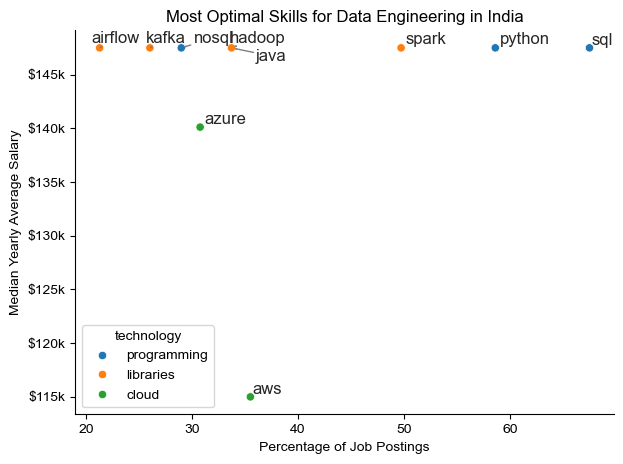

In [ ]:
from adjustText import adjust_text

# df_plot.plot(kind='scatter', x='skill_percent', y='median_salary')
sns.scatterplot(
    data = df_plot,
    x= 'skill_percent',
    y= 'median_salary',
    hue = 'technology'
)
sns.despine()
sns.set_theme(style='ticks')
# preparing texts for adjustmnt
texts=[]
for i, txt in enumerate(
    df_DE_skills.index):
    texts.append(plt.text(
        df_DE_skills['skill_percent'].iloc[i], 
    df_DE_skills['median_salary'].iloc[i], txt))

# adjusting text to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle="->", color='gray',lw=1.0))

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}k'))
plt.xlabel('Percentage of Job Postings')
plt.ylabel('Median Yearly Average Salary')
plt.title('Most Optimal Skills for Data Engineering in India')
plt.tight_layout()
plt.show()